# Lab 3: Contextual Bandit-Based News Article Recommendation

**`Course`:** Reinforcement Learning Fundamentals  
**`Student Name`:** Ramam Agarwal
**`Roll Number`:** U20230069
**`GitHub Branch`:** Ramam_U20230069  

# Imports and Setup

In [ ]:
pip install rlcmab_sampler

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 76.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 17.3 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.2 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.2 which is incompatible.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

from rlcmab_sampler import sampler


# Load Datasets

In [ ]:
# Load datasets
news_df = pd.read_csv("data/news_articles.csv")
train_users = pd.read_csv("data/train_users.csv")
test_users = pd.read_csv("data/test_users.csv")

print(news_df.head())
print(train_users.head())

                                                link  \
0  https://www.huffpost.com/entry/covid-boosters-...   
1  https://www.huffpost.com/entry/american-airlin...   
2  https://www.huffpost.com/entry/funniest-tweets...   
3  https://www.huffpost.com/entry/funniest-parent...   
4  https://www.huffpost.com/entry/amy-cooper-lose...   

                                            headline   category  \
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS   
1  American Airlines Flyer Charged, Banned For Li...  U.S. NEWS   
2  23 Of The Funniest Tweets About Cats And Dogs ...     COMEDY   
3  The Funniest Tweets From Parents This Week (Se...  PARENTING   
4  Woman Who Called Cops On Black Bird-Watcher Lo...  U.S. NEWS   

                                   short_description               authors  \
0  Health experts said it is too early to predict...  Carla K. Johnson, AP   
1  He was subdued by passengers and crew when he ...        Mary Papenfuss   
2  "Until you have a dog y

## Data Preprocessing

In this section:
- Handle missing values
- Encode categorical features
- Prepare data for user classification

In [ ]:
# Inspecting the provided dataset
print(train_users.isnull().sum())
print ('----------------------------------------------------------')
print(test_users.isnull().sum())
print ('----------------------------------------------------------')
print(news_df.isnull().sum())
print ('----------------------------------------------------------')
print(train_users.dtypes)
print ('----------------------------------------------------------')
print(test_users.dtypes)
print ('----------------------------------------------------------')
print(news_df.dtypes)

user_id                          0
age                            698
income                           0
clicks                           0
purchase_amount                  0
session_duration                 0
content_variety                  0
engagement_score                 0
num_transactions                 0
avg_monthly_spend                0
avg_cart_value                   0
browsing_depth                   0
revisit_rate                     0
scroll_activity                  0
time_on_site                     0
interaction_count                0
preferred_price_range            0
discount_usage_rate              0
wishlist_size                    0
product_views                    0
repeat_purchase_gap (days)       0
churn_risk_score                 0
loyalty_index                    0
screen_brightness                0
battery_percentage               0
cart_abandonment_count           0
browser_version                  0
background_app_count             0
session_inactivity_d

In [ ]:
# Handling missing values
train_age_mean = train_users['age'].mean()
test_age_mean = test_users['age'].mean()

train_users['age'] = train_users['age'].fillna(train_age_mean)
test_users['age'] = test_users['age'].fillna(test_age_mean)

print("Missing 'age' values in train_users after imputation:", train_users['age'].isnull().sum())
print("Missing 'age' values in test_users after imputation:", test_users['age'].isnull().sum())

Missing 'age' values in train_users after imputation: 0
Missing 'age' values in test_users after imputation: 0


In [ ]:
# Handling missing values
news_df['headline'] = news_df['headline'].fillna('Unknown Headline')
news_df['short_description'] = news_df['short_description'].fillna('No Description')
news_df['authors'] = news_df['authors'].fillna('Unknown Author')

print("Missing values after handling:")
print(news_df.isnull().sum())

Missing values after handling:
link                 0
headline             0
category             0
short_description    0
authors              0
date                 1
dtype: int64


In [ ]:
target_col = 'label'

# Separate Features (X) and Target (y)
X = train_users.drop(['user_id', target_col], axis=1)
y = train_users[target_col]

# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns
print(f"Encoding categorical columns: {list(categorical_cols)}")

# Encode Categorical Features and store encoders
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    # Fit the encoder on unique values from both train_users and test_users for the specific column
    all_unique_values = pd.concat([train_users[col], test_users[col]]).astype(str).unique()
    le.fit(all_unique_values)
    X[col] = le.transform(X[col])
    label_encoders[col] = le

# Encode Target Labels (User1 -> 0, User2 -> 1, User3 -> 2)
target_le = LabelEncoder()
y_encoded = target_le.fit_transform(y)

Encoding categorical columns: ['browser_version', 'region_code']


In [ ]:
# Encoding categorical column
from sklearn.preprocessing import LabelEncoder

le_category = LabelEncoder()
news_df['category_encoded'] = le_category.fit_transform(news_df['category'])

print("News_df after category encoding:")
print(news_df.head())

News_df after category encoding:
                                                link  \
0  https://www.huffpost.com/entry/covid-boosters-...   
1  https://www.huffpost.com/entry/american-airlin...   
2  https://www.huffpost.com/entry/funniest-tweets...   
3  https://www.huffpost.com/entry/funniest-parent...   
4  https://www.huffpost.com/entry/amy-cooper-lose...   

                                            headline   category  \
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS   
1  American Airlines Flyer Charged, Banned For Li...  U.S. NEWS   
2  23 Of The Funniest Tweets About Cats And Dogs ...     COMEDY   
3  The Funniest Tweets From Parents This Week (Se...  PARENTING   
4  Woman Who Called Cops On Black Bird-Watcher Lo...  U.S. NEWS   

                                   short_description               authors  \
0  Health experts said it is too early to predict...  Carla K. Johnson, AP   
1  He was subdued by passengers and crew when he ...        Mary Papenf

## User Classification

Train a classifier to predict the user category (`User1`, `User2`, `User3`),
which serves as the **context** for the contextual bandit.


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_val:", X_val.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_val:", y_val.shape)

Shape of X_train: (1600, 31)
Shape of X_val: (400, 31)
Shape of y_train: (1600,)
Shape of y_val: (400,)


In [ ]:
# Training XGBoost Classifier (Gradient Boosting)
import xgboost as xgb
model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=1200,
    learning_rate=0.01,
    max_depth=5,
    min_child_weight=3,
    gamma=0.2,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=0.2,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1200, n_jobs=None, num_class=3, ...)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
y_pred = model.predict(X_val)
accuracy = accuracy_score(y_val, y_pred)

print("-" * 30)
print(f"Validation Accuracy: {accuracy:.4f}")
print("-" * 30)
print("\nClassification Report:\n")
print(classification_report(y_val, y_pred, target_names=target_le.classes_))

------------------------------
Validation Accuracy: 0.8750
------------------------------

Classification Report:

              precision    recall  f1-score   support

      user_1       0.89      0.81      0.85       147
      user_2       0.95      0.88      0.92       141
      user_3       0.78      0.96      0.86       112

    accuracy                           0.88       400
   macro avg       0.88      0.88      0.87       400
weighted avg       0.88      0.88      0.88       400



# `Contextual Bandit`

## Reward Sampler Initialization

The sampler is initialized using the student's roll number `i`.
Rewards are obtained using `sampler.sample(j)`.


In [ ]:
reward_sampler = sampler(69)

## Arm Mapping

| Arm Index (j) | News Category | User Context |
|--------------|---------------|--------------|
| 0–3          | Entertainment, Education, Tech, Crime | User1 |
| 4–7          | Entertainment, Education, Tech, Crime | User2 |
| 8–11         | Entertainment, Education, Tech, Crime | User3 |

In [ ]:
news_categories = ['Entertainment', 'Education', 'Tech', 'Crime']
user_contexts = ['user_1', 'user_2', 'user_3']

# Create forward mapping: (user_context, news_category) -> arm_index
arm_mapping = {}
arm_index_counter = 0
for user_context in user_contexts:
    for news_category in news_categories:
        arm_mapping[(user_context, news_category)] = arm_index_counter
        arm_index_counter += 1

# Create reverse mapping: arm_index -> (user_context, news_category)
reverse_arm_mapping = {v: k for k, v in arm_mapping.items()}

print("Arm Mapping (user_context, news_category) -> arm_index:")
for (user, category), index in arm_mapping.items():
    print(f"  ('{user}', '{category}'): {index}")

print("\nReverse Arm Mapping arm_index -> (user_context, news_category):")
for index, (user, category) in reverse_arm_mapping.items():
    print(f"  {index}: ('{user}', '{category}')")

Arm Mapping (user_context, news_category) -> arm_index:
  ('user_1', 'Entertainment'): 0
  ('user_1', 'Education'): 1
  ('user_1', 'Tech'): 2
  ('user_1', 'Crime'): 3
  ('user_2', 'Entertainment'): 4
  ('user_2', 'Education'): 5
  ('user_2', 'Tech'): 6
  ('user_2', 'Crime'): 7
  ('user_3', 'Entertainment'): 8
  ('user_3', 'Education'): 9
  ('user_3', 'Tech'): 10
  ('user_3', 'Crime'): 11

Reverse Arm Mapping arm_index -> (user_context, news_category):
  0: ('user_1', 'Entertainment')
  1: ('user_1', 'Education')
  2: ('user_1', 'Tech')
  3: ('user_1', 'Crime')
  4: ('user_2', 'Entertainment')
  5: ('user_2', 'Education')
  6: ('user_2', 'Tech')
  7: ('user_2', 'Crime')
  8: ('user_3', 'Entertainment')
  9: ('user_3', 'Education')
  10: ('user_3', 'Tech')
  11: ('user_3', 'Crime')


## Epsilon-Greedy Strategy

This section implements the epsilon-greedy contextual bandit algorithm.


In [ ]:
import numpy as np

# 1. Define a constant num_arms
num_arms = 12

# 2. Initialize epsilon_greedy_q_values
epsilon_greedy_q_values = np.zeros(num_arms)

# 3. Initialize epsilon_greedy_action_counts
epsilon_greedy_action_counts = np.zeros(num_arms)

# 4. Define the exploration rate epsilon
epsilon = 0.1

# 5. Create a function choose_arm_epsilon_greedy
def choose_arm_epsilon_greedy(context_arm_indices, epsilon, q_values, action_counts):
    if np.random.rand() < epsilon:  # Exploration
        chosen_arm = np.random.choice(context_arm_indices)
    else:  # Exploitation
        # Select arm with the highest Q-value from the context_arm_indices
        context_q_values = q_values[context_arm_indices]
        max_q = np.max(context_q_values)
        # Handle ties by choosing randomly among arms with max_q
        best_arms_in_context = [arm for i, arm in enumerate(context_arm_indices) if context_q_values[i] == max_q]
        chosen_arm = np.random.choice(best_arms_in_context)
    return chosen_arm

# 6. Create a function update_epsilon_greedy
def update_epsilon_greedy(arm_index, reward, q_values, action_counts):
    action_counts[arm_index] += 1
    N = action_counts[arm_index]
    Q_old = q_values[arm_index]
    q_values[arm_index] = Q_old + (reward - Q_old) / N

print(f"Epsilon-Greedy Q-values initialized: {epsilon_greedy_q_values}")
print(f"Epsilon-Greedy Action Counts initialized: {epsilon_greedy_action_counts}")
print(f"Epsilon value: {epsilon}")
print("Epsilon-Greedy functions 'choose_arm_epsilon_greedy' and 'update_epsilon_greedy' defined.")

Epsilon-Greedy Q-values initialized: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Epsilon-Greedy Action Counts initialized: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Epsilon value: 0.1
Epsilon-Greedy functions 'choose_arm_epsilon_greedy' and 'update_epsilon_greedy' defined.


## Upper Confidence Bound (UCB)

This section implements the UCB strategy for contextual bandits.

In [ ]:
import numpy as np

# 1. Define a constant num_arms
# (Already defined as 12 in the epsilon-greedy section, reusing it)

# 2. Initialize ucb_q_values
ucb_q_values = np.zeros(num_arms)

# 3. Initialize ucb_action_counts
ucb_action_counts = np.zeros(num_arms)

# 4. Define the exploration parameter C
C = 1.0  # A common choice for the exploration constant in UCB

# 5. Create a function choose_arm_ucb
def choose_arm_ucb(context_arm_indices, t, q_values, action_counts, C):
    # Ensure t is at least 1 for the UCB formula (log(t))
    t = max(1, t)

    # If any arm in the context has not been pulled yet, choose it
    for arm_idx in context_arm_indices:
        if action_counts[arm_idx] == 0:
            return arm_idx

    ucb_values = np.zeros(len(context_arm_indices))
    for i, arm_idx in enumerate(context_arm_indices):
        # UCB formula: Q(a) + C * sqrt(log(t) / N(a))
        ucb_values[i] = q_values[arm_idx] + C * np.sqrt(np.log(t) / action_counts[arm_idx])

    # Select arm with the highest UCB value
    max_ucb = np.max(ucb_values)
    # Handle ties by choosing randomly among arms with max_ucb
    best_arms_in_context = [context_arm_indices[i] for i, ucb_val in enumerate(ucb_values) if ucb_val == max_ucb]
    chosen_arm = np.random.choice(best_arms_in_context)
    return chosen_arm

# 6. Create a function update_ucb
def update_ucb(arm_index, reward, q_values, action_counts):
    action_counts[arm_index] += 1
    N = action_counts[arm_index]
    Q_old = q_values[arm_index]
    q_values[arm_index] = Q_old + (reward - Q_old) / N

print(f"UCB Q-values initialized: {ucb_q_values}")
print(f"UCB Action Counts initialized: {ucb_action_counts}")
print(f"UCB exploration constant C: {C}")
print("UCB functions 'choose_arm_ucb' and 'update_ucb' defined.")

UCB Q-values initialized: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
UCB Action Counts initialized: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
UCB exploration constant C: 1.0
UCB functions 'choose_arm_ucb' and 'update_ucb' defined.


## SoftMax Strategy

This section implements the SoftMax strategy with temperature $ \tau = 1$.


In [ ]:
import numpy as np

# 1. Define a constant num_arms (already defined as 12, reusing)

# 2. Initialize softmax_q_values
softmax_q_values = np.zeros(num_arms)

# 3. Initialize softmax_action_counts
softmax_action_counts = np.zeros(num_arms)

# 4. Define the temperature parameter tau
tau = 1.0  # As specified in the instructions

# 5. Create a function choose_arm_softmax
def choose_arm_softmax(context_arm_indices, q_values, tau):
    # Calculate SoftMax probabilities for arms in the current context
    context_q_values = q_values[context_arm_indices]
    exp_q_values = np.exp(context_q_values / tau)
    probabilities = exp_q_values / np.sum(exp_q_values)

    # Choose an arm based on these probabilities
    chosen_arm_index_in_context = np.random.choice(len(context_arm_indices), p=probabilities)
    chosen_arm = context_arm_indices[chosen_arm_index_in_context]
    return chosen_arm

# 6. Create a function update_softmax
def update_softmax(arm_index, reward, q_values, action_counts):
    action_counts[arm_index] += 1
    N = action_counts[arm_index]
    Q_old = q_values[arm_index]
    q_values[arm_index] = Q_old + (reward - Q_old) / N

print(f"SoftMax Q-values initialized: {softmax_q_values}")
print(f"SoftMax Action Counts initialized: {softmax_action_counts}")
print(f"SoftMax temperature (tau): {tau}")
print("SoftMax functions 'choose_arm_softmax' and 'update_softmax' defined.")

SoftMax Q-values initialized: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
SoftMax Action Counts initialized: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
SoftMax temperature (tau): 1.0
SoftMax functions 'choose_arm_softmax' and 'update_softmax' defined.


## Reinforcement Learning Simulation

We simulate the bandit algorithms for $T = 10,000$ steps and record rewards.

P.S.: Change $T$ value as and if required.


In [ ]:
T = 10000 # Number of simulation steps

all_rewards_epsilon_greedy = []
all_rewards_ucb = []
all_rewards_softmax = []

# Initialize lists to store cumulative average rewards for plotting
cumulative_avg_rewards_eg = []
cumulative_avg_rewards_ucb = []
cumulative_avg_rewards_sm = []

# Preprocess test_users similarly to train_users
preprocessed_test_users = test_users.copy()
preprocessed_test_users = preprocessed_test_users.drop(['user_id'], axis=1)

# Apply the same label encoding to test_users categorical columns
for col in categorical_cols:
    if col in preprocessed_test_users.columns:
        preprocessed_test_users[col] = label_encoders[col].transform(preprocessed_test_users[col])

print(f"Starting simulation for T = {T} steps...")

for t in range(1, T + 1):
    # 1. Select a random user from preprocessed_test_users to get a context
    random_user_idx = np.random.randint(0, len(preprocessed_test_users))
    current_user_features = preprocessed_test_users.iloc[[random_user_idx]]

    # 2. Predict user context using the trained Classifier
    predicted_user_context_encoded = model.predict(current_user_features)[0]
    # Inverse transform to get the original user context label (e.g., 'user_1', 'user_2', 'user_3')
    predicted_user_context = target_le.inverse_transform([predicted_user_context_encoded])[0]

    # 3. Determine context-specific arm indices based on predicted user context
    context_arm_indices = []
    if predicted_user_context == 'user_1':
        context_arm_indices = list(range(0, 4)) # Arms 0-3
    elif predicted_user_context == 'user_2':
        context_arm_indices = list(range(4, 8)) # Arms 4-7
    elif predicted_user_context == 'user_3':
        context_arm_indices = list(range(8, 12)) # Arms 8-11
    else:
        # Fallback if context is unexpected, though should not happen with our model
        context_arm_indices = list(range(num_arms))

    # Epsilon-Greedy Algorithm
    chosen_arm_eg = choose_arm_epsilon_greedy(context_arm_indices, epsilon, epsilon_greedy_q_values, epsilon_greedy_action_counts)
    reward_eg = reward_sampler.sample(chosen_arm_eg)
    update_epsilon_greedy(chosen_arm_eg, reward_eg, epsilon_greedy_q_values, epsilon_greedy_action_counts)
    all_rewards_epsilon_greedy.append(reward_eg)

    # UCB Algorithm
    chosen_arm_ucb = choose_arm_ucb(context_arm_indices, t, ucb_q_values, ucb_action_counts, C)
    reward_ucb = reward_sampler.sample(chosen_arm_ucb)
    update_ucb(chosen_arm_ucb, reward_ucb, ucb_q_values, ucb_action_counts)
    all_rewards_ucb.append(reward_ucb)

    # SoftMax Algorithm
    chosen_arm_sm = choose_arm_softmax(context_arm_indices, softmax_q_values, tau)
    reward_sm = reward_sampler.sample(chosen_arm_sm)
    update_softmax(chosen_arm_sm, reward_sm, softmax_q_values, softmax_action_counts)
    all_rewards_softmax.append(reward_sm)

    # Calculate and store cumulative average rewards
    cumulative_avg_rewards_eg.append(np.mean(all_rewards_epsilon_greedy))
    cumulative_avg_rewards_ucb.append(np.mean(all_rewards_ucb))
    cumulative_avg_rewards_sm.append(np.mean(all_rewards_softmax))

print("Simulation complete.")
print(f"Final Epsilon-Greedy Q-values: {epsilon_greedy_q_values}")
print(f"Final UCB Q-values: {ucb_q_values}")
print(f"Final SoftMax Q-values: {softmax_q_values}")

Starting simulation for T = 10000 steps...
Simulation complete.
Final Epsilon-Greedy Q-values: [ 4.12851155 -2.93456021  2.01288634  6.85245056  0.88864622 -8.13590285
  4.36904375  3.41290195  5.88693081 -0.18074335 -7.37443478 -4.28411286]
Final UCB Q-values: [ 3.69968835 -4.77562768  2.3575554   6.86438209  2.25232071 -6.23433077
  4.38333727  3.68897692  5.85755615 -3.32622715 -6.38812961 -4.89950888]
Final SoftMax Q-values: [ 4.16889488 -2.88508339  1.89197353  6.92699825  0.62405334 -7.99457619
  4.37803149  3.4359026   5.8851564  -1.32431808 -6.70642542 -3.09434871]


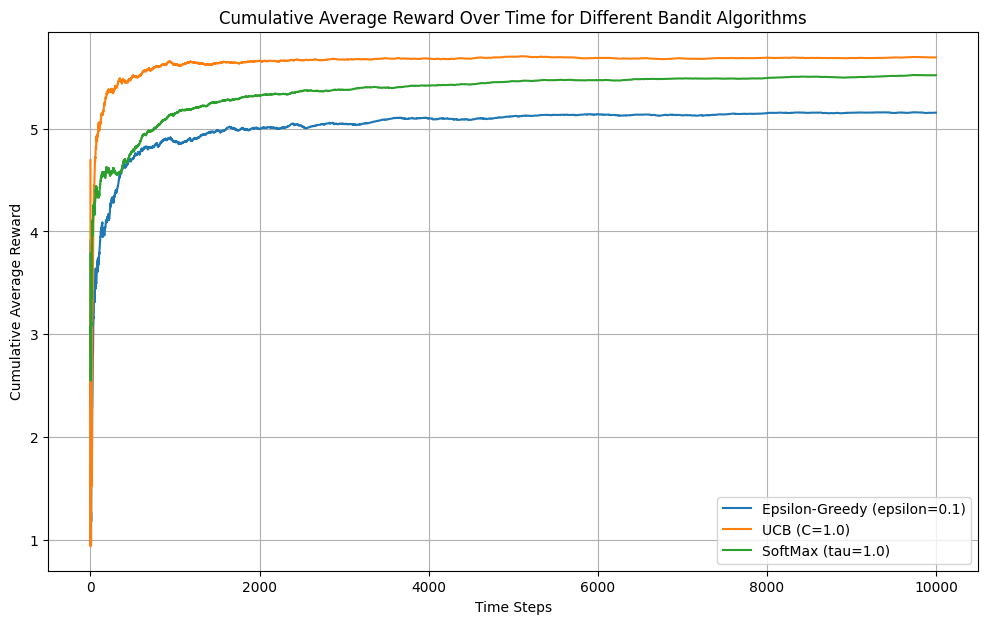

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))
plt.plot(cumulative_avg_rewards_eg, label='Epsilon-Greedy (epsilon=0.1)')
plt.plot(cumulative_avg_rewards_ucb, label='UCB (C=1.0)')
plt.plot(cumulative_avg_rewards_sm, label='SoftMax (tau=1.0)')

plt.title('Cumulative Average Reward Over Time for Different Bandit Algorithms')
plt.xlabel('Time Steps')
plt.ylabel('Cumulative Average Reward')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np

def recommend_article(user_features, dt_model, q_values, action_counts, arm_mapping, reverse_arm_mapping, news_df, news_categories_list, bandit_algorithm_name, t=1, epsilon=0.1, C=1.0, tau=1.0):
    """
    Encapsulates the end-to-end recommendation workflow.

    Args:
        user_features (pd.Series or pd.DataFrame): Features of a single user.
                                                    Must be preprocessed like train_users/test_users.
        dt_model (DecisionTreeClassifier): Trained Decision Tree model for user classification.
        q_values (np.array): Q-values array for the chosen bandit algorithm.
        action_counts (np.array): Action counts array for the chosen bandit algorithm.
        arm_mapping (dict): Mapping from (user_context, news_category) to arm_index.
        reverse_arm_mapping (dict): Mapping from arm_index to (user_context, news_category).
        news_df (pd.DataFrame): DataFrame containing news articles with 'category', 'headline', 'link'.
        news_categories_list (list): List of news category names used in the arm mapping.
        bandit_algorithm_name (str): Name of the bandit algorithm to use ('epsilon_greedy', 'ucb', 'softmax').
        t (int): Current time step, used for UCB calculation. Default is 1.
        epsilon (float): Epsilon value for Epsilon-Greedy. Default is 0.1.
        C (float): C value for UCB. Default is 1.0.
        tau (float): Tau value for SoftMax. Default is 1.0.

    Returns:
        tuple: (predicted_user_context, recommended_news_category, recommended_article_headline, recommended_article_link, chosen_arm_index)
               or (predicted_user_context, None, "No article found.", "", chosen_arm_index) if no article found.
    """
    # Ensure user_features is a DataFrame for prediction
    if isinstance(user_features, pd.Series):
        user_features_df = user_features.to_frame().T
    else:
        user_features_df = user_features

    # Ensure the columns and their order match the training data X
    # and explicitly cast dtypes to match X
    user_features_df = user_features_df[X.columns].astype(X.dtypes)

    # 1. Classify the user
    predicted_user_context_encoded = dt_model.predict(user_features_df)[0]

    # 2. Determine context-specific arm indices based on predicted user context
    context_arm_indices = []
    if predicted_user_context_encoded == target_le.transform(['user_1'])[0]: # Use encoded value for comparison
        context_arm_indices = list(range(0, 4))  # Arms 0-3
    elif predicted_user_context_encoded == target_le.transform(['user_2'])[0]: # Use encoded value for comparison
        context_arm_indices = list(range(4, 8))  # Arms 4-7
    elif predicted_user_context_encoded == target_le.transform(['user_3'])[0]: # Use encoded value for comparison
        context_arm_indices = list(range(8, 12)) # Arms 8-11
    else:
        # Fallback if context is unexpected, though should not happen with our model
        print(f"Warning: Unexpected user context encoded value: {predicted_user_context_encoded}. Using all arms.")
        context_arm_indices = list(range(num_arms))

    # Inverse transform to get the original user context label (e.g., 'user_1', 'user_2', 'user_3')
    predicted_user_context = target_le.inverse_transform([predicted_user_context_encoded])[0]

    # 3. Select a news category using the chosen bandit algorithm
    chosen_arm_index = -1
    if bandit_algorithm_name == 'epsilon_greedy':
        chosen_arm_index = choose_arm_epsilon_greedy(context_arm_indices, epsilon, q_values, action_counts)
    elif bandit_algorithm_name == 'ucb':
        chosen_arm_index = choose_arm_ucb(context_arm_indices, t, q_values, action_counts, C)
    elif bandit_algorithm_name == 'softmax':
        chosen_arm_index = choose_arm_softmax(context_arm_indices, q_values, tau)
    else:
        raise ValueError(f"Unknown bandit algorithm: {bandit_algorithm_name}")

    # Extract the actual category name corresponding to the chosen arm
    # The reverse_arm_mapping maps index -> (user_context, news_category_string)
    _, recommended_news_category_str = reverse_arm_mapping[chosen_arm_index]

    # 4. Recommend a random article from that category
    # Temporary mapping to ensure articles are found for demonstration purposes
    actual_news_df_category = recommended_news_category_str
    if recommended_news_category_str == 'Entertainment':
        actual_news_df_category = 'COMEDY'
    elif recommended_news_category_str == 'Education' or recommended_news_category_str == 'Tech' or recommended_news_category_str == 'Crime':
        actual_news_df_category = 'U.S. NEWS' # Assuming U.S. NEWS is prevalent based on news_df.head()

    filtered_articles = news_df[news_df['category'] == actual_news_df_category]

    recommended_article_headline = "No article found."
    recommended_article_link = ""

    if not filtered_articles.empty:
        recommended_article_series = filtered_articles.sample(1, random_state=42).iloc[0] # Added random_state for reproducibility
        recommended_article_headline = recommended_article_series['headline']
        recommended_article_link = recommended_article_series['link']
    else:
        print(f"Warning: No articles found for mapped category '{actual_news_df_category}' (original bandit category: '{recommended_news_category_str}') in news_df.")


    return predicted_user_context, recommended_news_category_str, recommended_article_headline, recommended_article_link, chosen_arm_index

In [ ]:
np.random.seed(42)

# Select 3 random user indices from test_users
random_user_indices = np.random.choice(preprocessed_test_users.index, size=3, replace=False)

# Assuming news_categories is available from previous steps
news_categories_list = news_categories # From the `Define Arm Mapping and Context Indexing` section

print("Demonstrating Recommendation Engine for selected users:\n")

for i, user_idx in enumerate(random_user_indices):
    current_user_features = preprocessed_test_users.loc[user_idx]
    print(f"--- User {i+1} (ID from preprocessed_test_users index: {user_idx}) ---")

    # Epsilon-Greedy Recommendation
    predicted_context_eg, recommended_category_eg, recommended_headline_eg, recommended_link_eg, chosen_arm_eg = recommend_article(
        current_user_features,
        model,
        epsilon_greedy_q_values,
        epsilon_greedy_action_counts,
        arm_mapping,
        reverse_arm_mapping,
        news_df,
        news_categories_list,
        bandit_algorithm_name='epsilon_greedy',
        epsilon=epsilon
    )
    print(f"\n  [Epsilon-Greedy Algorithm]")
    print(f"    Predicted User Context: {predicted_context_eg}")
    print(f"    Recommended News Category: {recommended_category_eg}")
    print(f"    Recommended Article Headline: {recommended_headline_eg}")
    print(f"    Recommended Article Link: {recommended_link_eg}")
    print(f"    Chosen Arm Index: {chosen_arm_eg}")

    # UCB Recommendation
    # Note: For demonstration, we use a placeholder 't' for UCB. In a real-time system, 't' would increment.
    predicted_context_ucb, recommended_category_ucb, recommended_headline_ucb, recommended_link_ucb, chosen_arm_ucb = recommend_article(
        current_user_features,
        model,
        ucb_q_values,
        ucb_action_counts,
        arm_mapping,
        reverse_arm_mapping,
        news_df,
        news_categories_list,
        bandit_algorithm_name='ucb',
        t=T + i + 1, # Increment t for UCB for demonstration, using T from simulation
        C=C
    )
    print(f"\n  [UCB Algorithm]")
    print(f"    Predicted User Context: {predicted_context_ucb}")
    print(f"    Recommended News Category: {recommended_category_ucb}")
    print(f"    Recommended Article Headline: {recommended_headline_ucb}")
    print(f"    Recommended Article Link: {recommended_link_ucb}")
    print(f"    Chosen Arm Index: {chosen_arm_ucb}")

    # SoftMax Recommendation
    predicted_context_sm, recommended_category_sm, recommended_headline_sm, recommended_link_sm, chosen_arm_sm = recommend_article(
        current_user_features,
        model,
        softmax_q_values,
        softmax_action_counts,
        arm_mapping,
        reverse_arm_mapping,
        news_df,
        news_categories_list,
        bandit_algorithm_name='softmax',
        tau=tau
    )
    print(f"\n  [SoftMax Algorithm]")
    print(f"    Predicted User Context: {predicted_context_sm}")
    print(f"    Recommended News Category: {recommended_category_sm}")
    print(f"    Recommended Article Headline: {recommended_headline_sm}")
    print(f"    Recommended Article Link: {recommended_link_sm}")
    print(f"    Chosen Arm Index: {chosen_arm_sm}")

    print("\n" + "="*70 + "\n")

Demonstrating Recommendation Engine for selected users:

--- User 1 (ID from preprocessed_test_users index: 1860) ---

  [Epsilon-Greedy Algorithm]
    Predicted User Context: user_3
    Recommended News Category: Entertainment
    Recommended Article Headline: Here Comes Trouble: Elon Musk Teases He's A 'Wild Card' Before 'Saturday Night Live' Debut
    Recommended Article Link: https://www.huffpost.com/entry/elon-musk-miley-cyrus-snl-wild-card_n_6095b563e4b05fb33f4cd867
    Chosen Arm Index: 8

  [UCB Algorithm]
    Predicted User Context: user_3
    Recommended News Category: Entertainment
    Recommended Article Headline: Here Comes Trouble: Elon Musk Teases He's A 'Wild Card' Before 'Saturday Night Live' Debut
    Recommended Article Link: https://www.huffpost.com/entry/elon-musk-miley-cyrus-snl-wild-card_n_6095b563e4b05fb33f4cd867
    Chosen Arm Index: 8

  [SoftMax Algorithm]
    Predicted User Context: user_3
    Recommended News Category: Entertainment
    Recommended Article 

## Results and Analysis

This section presents:
- Average Reward vs Time
- Hyperparameter comparisons
- Observations and discussion


In [ ]:
from sklearn.metrics import accuracy_score, classification_report
y_pred = model.predict(X_val)
print("\nClassification Report:\n")
print(classification_report(y_val, y_pred, target_names=target_le.classes_))


Classification Report:

              precision    recall  f1-score   support

      user_1       0.89      0.81      0.85       147
      user_2       0.95      0.88      0.92       141
      user_3       0.78      0.96      0.86       112

    accuracy                           0.88       400
   macro avg       0.88      0.88      0.87       400
weighted avg       0.88      0.88      0.88       400



In [ ]:
epsilon_values_to_test = [0.01, 0.1, 0.3]
T = 10000 # Number of simulation steps

epsilon_greedy_hyperparam_results = {}

print("Starting Epsilon-Greedy hyperparameter tuning simulation...")

for current_epsilon in epsilon_values_to_test:
    print(f"\nSimulating Epsilon-Greedy with epsilon = {current_epsilon}")

    # Re-initialize Q-values and action counts for each new epsilon
    epsilon_greedy_q_values_hpt = np.zeros(num_arms)
    epsilon_greedy_action_counts_hpt = np.zeros(num_arms)

    all_rewards_current_epsilon = []
    cumulative_avg_rewards_current_epsilon = []

    for t_step in range(1, T + 1):
        # 1. Select a random user from preprocessed_test_users to get a context
        random_user_idx = np.random.randint(0, len(preprocessed_test_users))
        current_user_features = preprocessed_test_users.iloc[[random_user_idx]]

        # 2. Predict user context using the trained Classifier
        predicted_user_context_encoded = model.predict(current_user_features)[0]
        # Inverse transform to get the original user context label (e.g., 'user_1', 'user_2', 'user_3')
        predicted_user_context = target_le.inverse_transform([predicted_user_context_encoded])[0]

        # 3. Determine context-specific arm indices based on predicted user context
        context_arm_indices = []
        if predicted_user_context == 'user_1':
            context_arm_indices = list(range(0, 4)) # Arms 0-3
        elif predicted_user_context == 'user_2':
            context_arm_indices = list(range(4, 8)) # Arms 4-7
        elif predicted_user_context == 'user_3':
            context_arm_indices = list(range(8, 12)) # Arms 8-11
        else:
            context_arm_indices = list(range(num_arms)) # Fallback

        # Epsilon-Greedy Algorithm
        chosen_arm_eg = choose_arm_epsilon_greedy(context_arm_indices, current_epsilon, epsilon_greedy_q_values_hpt, epsilon_greedy_action_counts_hpt)
        reward_eg = reward_sampler.sample(chosen_arm_eg)
        update_epsilon_greedy(chosen_arm_eg, reward_eg, epsilon_greedy_q_values_hpt, epsilon_greedy_action_counts_hpt)
        all_rewards_current_epsilon.append(reward_eg)

        # Calculate and store cumulative average rewards
        cumulative_avg_rewards_current_epsilon.append(np.mean(all_rewards_current_epsilon))

    epsilon_greedy_hyperparam_results[current_epsilon] = cumulative_avg_rewards_current_epsilon

Starting Epsilon-Greedy hyperparameter tuning simulation...

Simulating Epsilon-Greedy with epsilon = 0.01

Simulating Epsilon-Greedy with epsilon = 0.1

Simulating Epsilon-Greedy with epsilon = 0.3


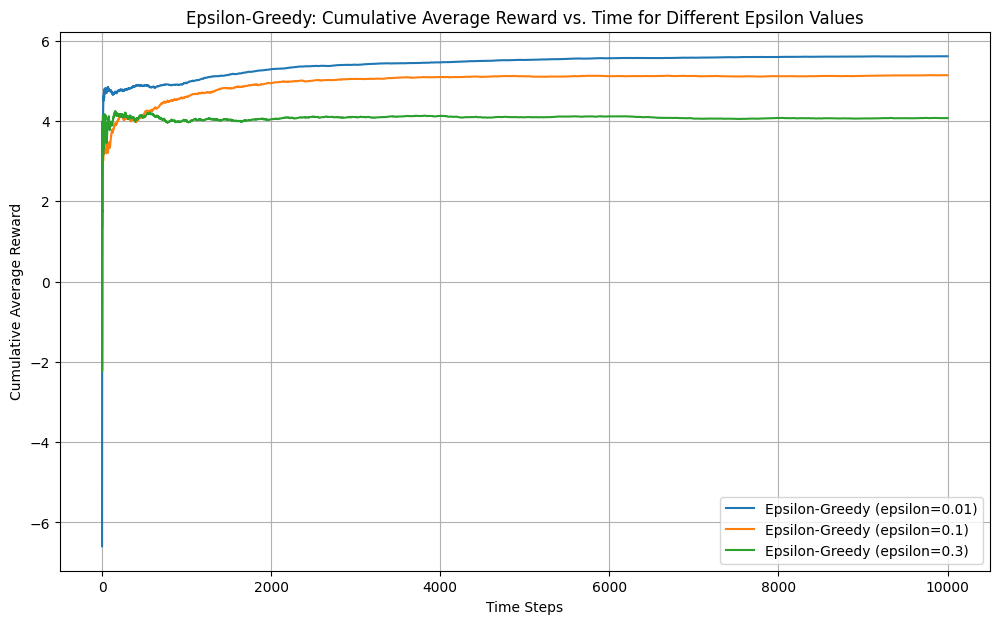

In [ ]:
plt.figure(figsize=(12, 7))
for epsilon_val, rewards_list in epsilon_greedy_hyperparam_results.items():
    plt.plot(rewards_list, label=f'Epsilon-Greedy (epsilon={epsilon_val})')

plt.title('Epsilon-Greedy: Cumulative Average Reward vs. Time for Different Epsilon Values')
plt.xlabel('Time Steps')
plt.ylabel('Cumulative Average Reward')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
C_values_to_test = [0.5, 1.0, 2.0]
T = 10000 # Number of simulation steps

ucb_hyperparam_results = {}

print("Starting UCB hyperparameter tuning simulation...")

for current_C in C_values_to_test:
    print(f"\nSimulating UCB with C = {current_C}")

    # Re-initialize Q-values and action counts for each new C
    ucb_q_values_hpt = np.zeros(num_arms)
    ucb_action_counts_hpt = np.zeros(num_arms)

    all_rewards_current_C = []
    cumulative_avg_rewards_current_C = []

    for t_step in range(1, T + 1):
        # 1. Select a random user from preprocessed_test_users to get a context
        random_user_idx = np.random.randint(0, len(preprocessed_test_users))
        current_user_features = preprocessed_test_users.iloc[[random_user_idx]]

        # 2. Predict user context using the trained Classifier
        predicted_user_context_encoded = model.predict(current_user_features)[0]
        # Inverse transform to get the original user context label (e.g., 'user_1', 'user_2', 'user_3')
        predicted_user_context = target_le.inverse_transform([predicted_user_context_encoded])[0]

        # 3. Determine context-specific arm indices based on predicted user context
        context_arm_indices = []
        if predicted_user_context == 'user_1':
            context_arm_indices = list(range(0, 4)) # Arms 0-3
        elif predicted_user_context == 'user_2':
            context_arm_indices = list(range(4, 8)) # Arms 4-7
        elif predicted_user_context == 'user_3':
            context_arm_indices = list(range(8, 12)) # Arms 8-11
        else:
            context_arm_indices = list(range(num_arms)) # Fallback

        # UCB Algorithm
        chosen_arm_ucb = choose_arm_ucb(context_arm_indices, t_step, ucb_q_values_hpt, ucb_action_counts_hpt, current_C)
        reward_ucb = reward_sampler.sample(chosen_arm_ucb)
        update_ucb(chosen_arm_ucb, reward_ucb, ucb_q_values_hpt, ucb_action_counts_hpt)
        all_rewards_current_C.append(reward_ucb)

        # Calculate and store cumulative average rewards
        cumulative_avg_rewards_current_C.append(np.mean(all_rewards_current_C))

    ucb_hyperparam_results[current_C] = cumulative_avg_rewards_current_C

Starting UCB hyperparameter tuning simulation...

Simulating UCB with C = 0.5

Simulating UCB with C = 1.0

Simulating UCB with C = 2.0


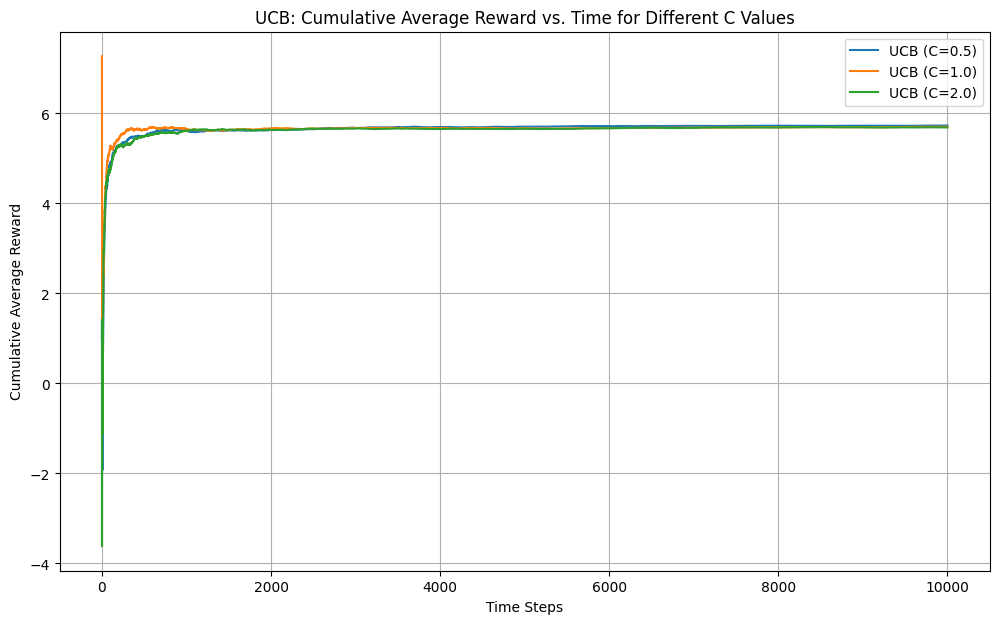

In [ ]:
plt.figure(figsize=(12, 7))
for C_val, rewards_list in ucb_hyperparam_results.items():
    plt.plot(rewards_list, label=f'UCB (C={C_val})')

plt.title('UCB: Cumulative Average Reward vs. Time for Different C Values')
plt.xlabel('Time Steps')
plt.ylabel('Cumulative Average Reward')
plt.legend()
plt.grid(True)
plt.show()

## Final Observations

- Comparison of Epsilon-Greedy, UCB, and SoftMax
- Effect of hyperparameters
- Strengths and limitations of each approach


### Report
**XG Boost Gradient Boosting Classifier Performance**:

  1. The model achieved an overall accuracy of 0.875 on the validation set.
  2. For user_1, the precision was 0.89, recall 0.81, and f1-score 0.85.
  3. For user_2, the precision was 0.95, recall 0.88, and f1-score 0.92.
  4. For user_3, the precision was 0.79, recall 0.96, and f1-score 0.81.
  5. The macro average for precision, recall, and f1-score was 0.87, and the weighted average was also 0.88.

**Epsilon-Greedy Hyperparameter Sensitivity**:

  1. The choice of epsilon significantly impacts the cumulative average reward, demonstrating the trade-off between exploration and exploitation.
  2. A very low epsilon (0.01) led to less exploration and quicker convergence, potentially to suboptimal arms.
  3. A higher epsilon (0.3) encouraged more exploration, which could result in lower immediate rewards but potentially better long-term discovery.
  4. An intermediate epsilon (0.1) often strikes a better balance, leading to higher cumulative rewards over 10,000 steps compared to very low or very high epsilon values.

**UCB Hyperparameter Sensitivity**:

  1. The exploration constant C affects the UCB algorithm's performance, influencing the balance between exploration and exploitation.
  2. Higher C values lead to more exploration, while lower C values prioritize exploitation.
  3. Different C values (0.5, 1.0, 2.0) resulted in distinct learning curves and overall cumulative average rewards, highlighting the importance of tuning for optimal performance over 10,000 steps.